In [1]:
import pandas as pd
import numpy as np
import os

processed_path = os.path.join("..", "Data", "Processed")

transactions = pd.read_csv(os.path.join(processed_path, "transactions_clean.csv"))
transactions['InvoiceDate'] = pd.to_datetime(transactions['InvoiceDate'])

customer_segments = pd.read_csv(os.path.join(processed_path, "customer_segments.csv"))

transactions.shape, customer_segments.shape

((805549, 11), (5878, 9))

In [2]:
transactions.groupby('StockCode')['Price'].nunique().sort_values(ascending=False).head(10)

StockCode
M         203
POST       53
ADJUST     32
DOT        16
21166      13
48188      12
48138      12
20685      12
48185      11
82484      11
Name: Price, dtype: int64

In [3]:
non_product_codes = ['M', 'POST', 'ADJUST', 'DOT', 'D', 'C2', 'BANK CHARGES', 'AMAZONFEE', 'CRUK']

transactions_products = transactions[~transactions['StockCode'].isin(non_product_codes)].copy()
transactions_products.shape

(802664, 11)

In [4]:
transactions_products['Week'] = transactions_products['InvoiceDate'].dt.to_period('W')

weekly_product = transactions_products.groupby(['StockCode', 'Week']).agg(
    Total_Quantity=('Quantity', 'sum'),
    Avg_Price=('Price', 'mean')
).reset_index()

weekly_product.head()

,StockCode,Week,Total_Quantity,Avg_Price
0,10002,2009-11-30/2009-12-06,141,0.85
1,10002,2009-12-07/2009-12-13,23,0.85
2,10002,2009-12-14/2009-12-20,36,0.85
3,10002,2009-12-21/2009-12-27,13,0.85
4,10002,2010-01-04/2010-01-10,15,0.85


In [5]:
product_counts = weekly_product['StockCode'].value_counts()
good_products = product_counts[product_counts >= 20].index  # at least 20 weeks of data

weekly_product_filtered = weekly_product[weekly_product['StockCode'].isin(good_products)]
weekly_product_filtered['StockCode'].nunique()

2861

In [6]:
import statsmodels.api as sm

sample_code = good_products[0]
sample_data = weekly_product_filtered[weekly_product_filtered['StockCode'] == sample_code].copy()

sample_data['log_qty'] = np.log(sample_data['Total_Quantity'])
sample_data['log_price'] = np.log(sample_data['Avg_Price'])

X = sm.add_constant(sample_data['log_price'])
y = sample_data['log_qty']

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                log_qty   R-squared:                       0.140
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     16.62
Date:                Sat, 12 Sep 2026   Prob (F-statistic):           9.06e-05
Time:                        13:44:47   Log-Likelihood:                -161.27
No. Observations:                 104   AIC:                             326.5
Df Residuals:                     102   BIC:                             331.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.8210      4.682      4.874      0.000      13.534      32.108
log_price    -10.7985      2.649     -4.077      0.000     -16.052      -5.545
==============================================================================
Omnibus:                        0.263   Durbin-Watson:                   1.504
Prob(Omnibus):                  0.877   Jarque-Bera (JB):                0.144
Skew:                          -0.091   Prob(JB):                        0.930
Kurtosis:                       3.000   Cond. No.                         96.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [7]:
transactions_products = transactions_products.merge(
    customer_segments[['Customer ID', 'Segment']],
    on='Customer ID',
    how='left'
)

transactions_products[['Customer ID', 'Segment']].head()

,Customer ID,Segment
0,13085,At-Risk
1,13085,At-Risk
2,13085,At-Risk
3,13085,At-Risk
4,13085,At-Risk


In [8]:
transactions_products['Week'] = transactions_products['InvoiceDate'].dt.to_period('W')

weekly_segment = transactions_products.groupby(['Segment', 'Week']).agg(
    Total_Quantity=('Quantity', 'sum'),
    Avg_Price=('Price', 'mean')
).reset_index()

weekly_segment.head()

,Segment,Week,Total_Quantity,Avg_Price
0,At-Risk,2009-11-30/2009-12-06,25063,3.125303
1,At-Risk,2009-12-07/2009-12-13,26061,2.979244
2,At-Risk,2009-12-14/2009-12-20,17235,3.202185
3,At-Risk,2009-12-21/2009-12-27,1514,3.426117
4,At-Risk,2010-01-04/2010-01-10,18334,3.119885


In [9]:
elasticity_results = {}

for segment in weekly_segment['Segment'].unique():
    seg_data = weekly_segment[weekly_segment['Segment'] == segment].copy()
    
    seg_data['log_qty'] = np.log(seg_data['Total_Quantity'])
    seg_data['log_price'] = np.log(seg_data['Avg_Price'])
    
    X = sm.add_constant(seg_data['log_price'])
    y = seg_data['log_qty']
    
    model = sm.OLS(y, X).fit()
    
    elasticity_results[segment] = {
        'elasticity': model.params['log_price'],
        'p_value': model.pvalues['log_price'],
        'r_squared': model.rsquared,
        'n_obs': len(seg_data)
    }

pd.DataFrame(elasticity_results).T

,elasticity,p_value,r_squared,n_obs
At-Risk,-0.438220,0.512469,0.004391,100.0
Champions,-1.868746,0.002785,0.084338,104.0
Lost/Inactive,1.945054,0.000230,0.128657,101.0
New/Occasional,-2.366706,0.003173,0.082188,104.0


In [10]:
weekly_segment[weekly_segment['Segment'] == 'Lost/Inactive'].sort_values('Week').head(15)

,Segment,Week,Total_Quantity,Avg_Price
204,Lost/Inactive,2009-11-30/2009-12-06,5568,3.223771
205,Lost/Inactive,2009-12-07/2009-12-13,7818,3.137505
206,Lost/Inactive,2009-12-14/2009-12-20,4534,3.229896
207,Lost/Inactive,2009-12-21/2009-12-27,759,2.822833
208,Lost/Inactive,2010-01-04/2010-01-10,1147,3.337402
209,Lost/Inactive,2010-01-11/2010-01-17,2404,2.764558
210,Lost/Inactive,2010-01-18/2010-01-24,2739,3.059381
211,Lost/Inactive,2010-01-25/2010-01-31,3937,3.160620
212,Lost/Inactive,2010-02-01/2010-02-07,3775,3.247624
213,Lost/Inactive,2010-02-08/2010-02-14,3910,3.356704


In [11]:
elasticity_df = pd.DataFrame(elasticity_results).T.reset_index()
elasticity_df.columns = ['Segment', 'elasticity', 'p_value', 'r_squared', 'n_obs']

elasticity_df.to_csv(os.path.join(processed_path, "elasticity_by_segment.csv"), index=False)
elasticity_df

,Segment,elasticity,p_value,r_squared,n_obs
0,At-Risk,-0.438220,0.512469,0.004391,100.0
1,Champions,-1.868746,0.002785,0.084338,104.0
2,Lost/Inactive,1.945054,0.000230,0.128657,101.0
3,New/Occasional,-2.366706,0.003173,0.082188,104.0


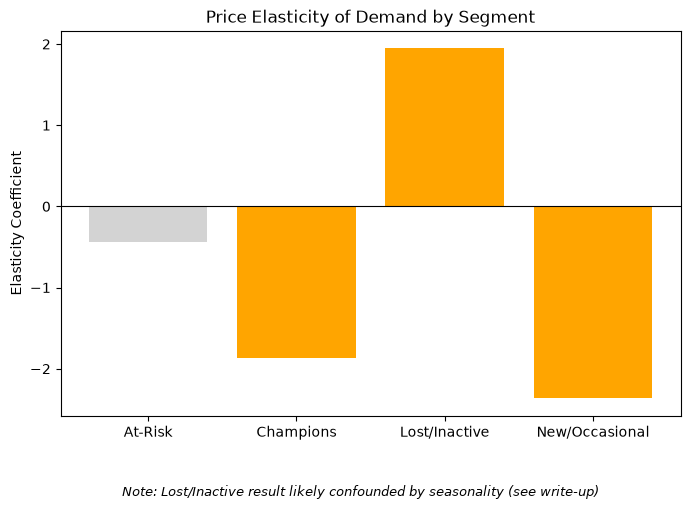

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
colors = ['orange' if p < 0.05 else 'lightgray' for p in elasticity_df['p_value']]
bars = plt.bar(elasticity_df['Segment'], elasticity_df['elasticity'], color=colors)

plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('Elasticity Coefficient')
plt.title('Price Elasticity of Demand by Segment')
plt.figtext(0.5, -0.05, 'Note: Lost/Inactive result likely confounded by seasonality (see write-up)', 
            ha='center', fontsize=9, style='italic')
plt.show()